# Fashion MNIST Classification - Fully Connected Neural Network

## 1. Імпорт бібліотек

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import keras_tuner as kt
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Встановлюємо random seeds для відтворюваності
np.random.seed(42)
tf.random.set_seed(42)

print("✓ Всі бібліотеки успішно імпортовані")

✓ Всі бібліотеки успішно імпортовані


## 2. Завантаження та підготовка даних

ЗАВАНТАЖЕННЯ DATASET Fashion MNIST

Train samples: 60000
Test samples: 10000
Image dimensions: 28x28

Кількість класів: 10
ПІДГОТОВКА ДАНИХ

Вхідна форма після флату: (60000, 784)
Кількість ф'ючарів: 784
Форма one-hot лейблів: (60000, 10)


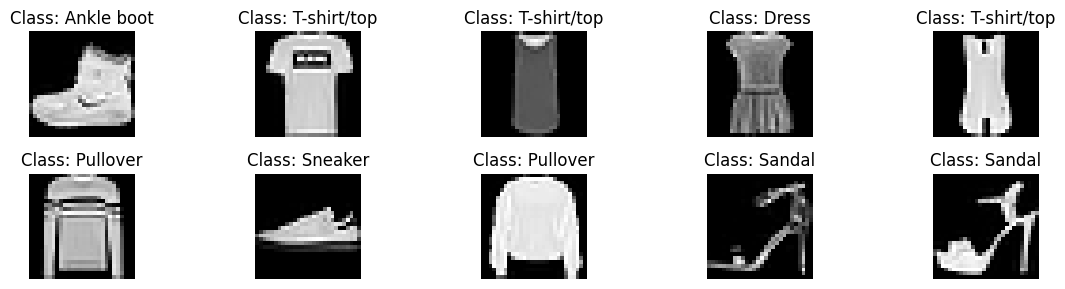

In [16]:
print("=" * 60)
print("ЗАВАНТАЖЕННЯ DATASET Fashion MNIST")
print("=" * 60)

# Завантажуємо Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print(f"\nTrain samples: {x_train.shape[0]}")
print(f"Test samples: {x_test.shape[0]}")
print(f"Image dimensions: {x_train.shape[1]}x{x_train.shape[2]}")

# Назви класів
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"\nКількість класів: {len(class_names)}")

print("=" * 60)
print("ПІДГОТОВКА ДАНИХ")
print("=" * 60)

# Нормалізуємо піксельні значення до [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# ФЛАТОВАННЯ: перетворюємо 28x28 зображення в 784-вимірні вектори
# НЕ ВИКОРИСТОВУЄМО ЗГОРТКОВІ ШАРИ!
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

print(f"\nВхідна форма після флату: {x_train_flat.shape}")
print(f"Кількість ф'ючарів: {x_train_flat.shape[1]}")

# One-hot кодування лейблів
num_classes = 10
y_train_categorical = keras.utils.to_categorical(y_train, num_classes)
y_test_categorical = keras.utils.to_categorical(y_test, num_classes)

print(f"Форма one-hot лейблів: {y_train_categorical.shape}")

# Візуалізація деяких зразків
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Class: {class_names[y_train[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## 3. Функція побудови моделі для Keras Tuner

In [17]:
def build_model(hp):
    """
    Будуємо повністю з'єднану нейронну мережу з регульованими гіперпараметрами.
    БЕЗ ЗГОРТКОВИХ ШАРІВ - тільки Dense шари.
    
    Args:
        hp: Hyperparameter object from Keras Tuner
    
    Returns:
        compiled Keras model
    """
    model = models.Sequential()
    
    # Вхідний шар
    model.add(layers.Input(shape=(784,)))
    
    # Налаштовується кількість прихованих шарів (1-4)
    num_layers = hp.Int('num_layers', 1, 4, step=1)
    
    # Налаштовується кількість нейронів у кожному шарі
    units = hp.Int('units', 256, 512, step=128)
    
    # Додаємо приховані шари з dropout та регуляризацією
    for i in range(num_layers):
        model.add(layers.Dense(
            units,
            activation=hp.Choice(f'activation_{i}', ['relu', 'tanh']),
            kernel_regularizer=regularizers.l2(hp.Float(f'l2_reg_{i}', 1e-5, 1e-2, sampling='log'))
        ))
        
        # Налаштовується dropout rate для запобігання перенавчанню
        model.add(layers.Dropout(hp.Float(f'dropout_{i}', 0.3, 0.5, step=0.05)))
    
    # Вихідний шар з softmax активацією
    model.add(layers.Dense(num_classes, activation='softmax'))
    
    # Налаштовується learning rate для optimizer
    learning_rate = hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
    
    # Компілюємо модель
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

print("✓ Функція build_model створена")

✓ Функція build_model створена


## 4. Налаштування Keras Tuner (Hyperband)

In [18]:
print("=" * 60)
print("КЕРАС ТЮНЕР - HYPERBAND SEARCH")
print("=" * 60)

# Створюємо Hyperband tuner для автоматичного підбору гіперпараметрів
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=30,
    factor=3,
    directory='keras_tuner_logs',
    project_name='fashion_mnist_fc_tuner'
)

print(f"\nTuner: Hyperband")
print(f"Objective: val_accuracy")
print(f"Max epochs: 30")
print(f"Directory: keras_tuner_logs/fashion_mnist_fc_tuner")

# Callback для раннього зупину
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

# Callback для зменшення learning rate на плато
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

print("✓ Callbacks створені:")
print(f"  - EarlyStopping (patience=7)")
print(f"  - ReduceLROnPlateau (factor=0.5, patience=3)")

КЕРАС ТЮНЕР - HYPERBAND SEARCH
Reloading Tuner from keras_tuner_logs\fashion_mnist_fc_tuner\tuner0.json

Tuner: Hyperband
Objective: val_accuracy
Max epochs: 30
Directory: keras_tuner_logs/fashion_mnist_fc_tuner
✓ Callbacks створені:
  - EarlyStopping (patience=7)
  - ReduceLROnPlateau (factor=0.5, patience=3)


## 5. Пошук найкращих гіперпараметрів

In [19]:
print("=" * 60)
print("ПОШУК НАЙКРАЩИХ ГІПЕРАПАРМЕТРІВ")
print("=" * 60)
print("\nЦе може зайняти 15-25 хвилин...\n")

# Запускаємо пошук найкращих гіперпараметрів
tuner.search(
    x_train_flat, y_train_categorical,
    epochs=30,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\n" + "=" * 60)
print("ПОШУК ЗАВЕРШЕНО!")
print("=" * 60)

# Отримуємо найкращі гіперпараметри
best_hps = tuner.get_best_hyperparameters(1)[0]

print("\n" + "=" * 60)
print("НАЙКРАЩІ ГІПЕРАПАРМЕТРИ:")
print("=" * 60)
num_layers_best = best_hps.get('num_layers')
activation_list = [best_hps.get(f'activation_{i}') for i in range(num_layers_best)]
print(f"Кількість прихованих шарів: {num_layers_best}")
print(f"Кількість нейронів у шарах: {best_hps.get('units')}")
print(f"Learning rate: {best_hps.get('learning_rate'):.6f}")
print(f"Activation functions: {activation_list}")

print("=" * 60)

Trial 84 Complete [00h 03m 59s]
val_accuracy: 0.8811110854148865

Best val_accuracy So Far: 0.897777795791626
Total elapsed time: 01h 32m 20s

ПОШУК ЗАВЕРШЕНО!

НАЙКРАЩІ ГІПЕРАПАРМЕТРИ:
Кількість прихованих шарів: 1
Кількість нейронів у шарах: 256
Learning rate: 0.000502
Activation functions: ['relu']


## 6. Побудова та огляд архітектури найкращої моделі

In [20]:
# Будуємо модель з найкращими гіперпараметрами
best_model = tuner.hypermodel.build(best_hps)

print("=" * 60)
print("АРХІТЕКТУРА МОДЕЛІ (FULLY CONNECTED - NO CONV LAYERS)")
print("=" * 60)

# Показуємо архітектуру моделі
best_model.summary()

АРХІТЕКТУРА МОДЕЛІ (FULLY CONNECTED - NO CONV LAYERS)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Фінальне навчання моделі

In [21]:
print("=" * 60)
print("ФІНАЛЬНЕ НАВЧАННЯ МОДЕЛІ")
print("=" * 60)
print("\nНавчаємо до 100 епох з EarlyStopping...\n")

# Фінальне навчання з найкращими гіперпараметрами
history = best_model.fit(
    x_train_flat, y_train_categorical,
    epochs=100,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

ФІНАЛЬНЕ НАВЧАННЯ МОДЕЛІ

Навчаємо до 100 епох з EarlyStopping...

Epoch 1/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7926 - loss: 0.6268 - val_accuracy: 0.8403 - val_loss: 0.4702 - learning_rate: 5.0170e-04
Epoch 2/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8477 - loss: 0.4564 - val_accuracy: 0.8604 - val_loss: 0.4203 - learning_rate: 5.0170e-04
Epoch 3/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8609 - loss: 0.4142 - val_accuracy: 0.8666 - val_loss: 0.3991 - learning_rate: 5.0170e-04
Epoch 4/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8695 - loss: 0.3912 - val_accuracy: 0.8734 - val_loss: 0.3875 - learning_rate: 5.0170e-04
Epoch 5/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8769 - loss: 0.3734 - val_accuracy: 0.8750 - val_loss: 0.3803 - learning_rate: 5.0170e-04
Epoch 6/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8803 - loss: 0.3620 - val_accuracy: 0.8791 - val_loss: 0.3681 - learning_rate: 5.

## 8. Оцінка моделі на тестовому наборі

In [22]:
print("=" * 60)
print("ОЦІНКА МОДЕЛІ")
print("=" * 60)

# Оцінюємо модель на тестовому наборі
test_loss, test_accuracy = best_model.evaluate(x_test_flat, y_test_categorical, verbose=0)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")
print(f"\nЦільова точність: 0.88 - 0.90")
print(f"Досягнута точність: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")

if test_accuracy >= 0.88:
    print("\n✓ ЦІЛЬ ДОСЯГНУТА!")
else:
    print("\n⚠ Точність нижча за цільову (0.88)")

# Робимо прогнози на тестовому наборі
predictions = best_model.predict(x_test_flat)
predicted_labels = np.argmax(predictions, axis=1)

print(f"Форма прогнозів: {predictions.shape}")
print(f"Приклад перших 5 прогнозів: {predicted_labels[:5]}")
print(f"Відповідні true labels: {y_test[:5]}")

ОЦІНКА МОДЕЛІ

Test Loss: 0.3372
Test Accuracy: 0.8941 (89.41%)

Цільова точність: 0.88 - 0.90
Досягнута точність: 0.8941 (89.41%)

✓ ЦІЛЬ ДОСЯГНУТА!
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Форма прогнозів: (10000, 10)
Приклад перших 5 прогнозів: [9 2 1 1 6]
Відповідні true labels: [9 2 1 1 6]


## 9. Візуалізація результатів

✓ Директорія 'output_plots' створена
ГРАФІК 1: Тренувальна історія (Accuracy та Loss)


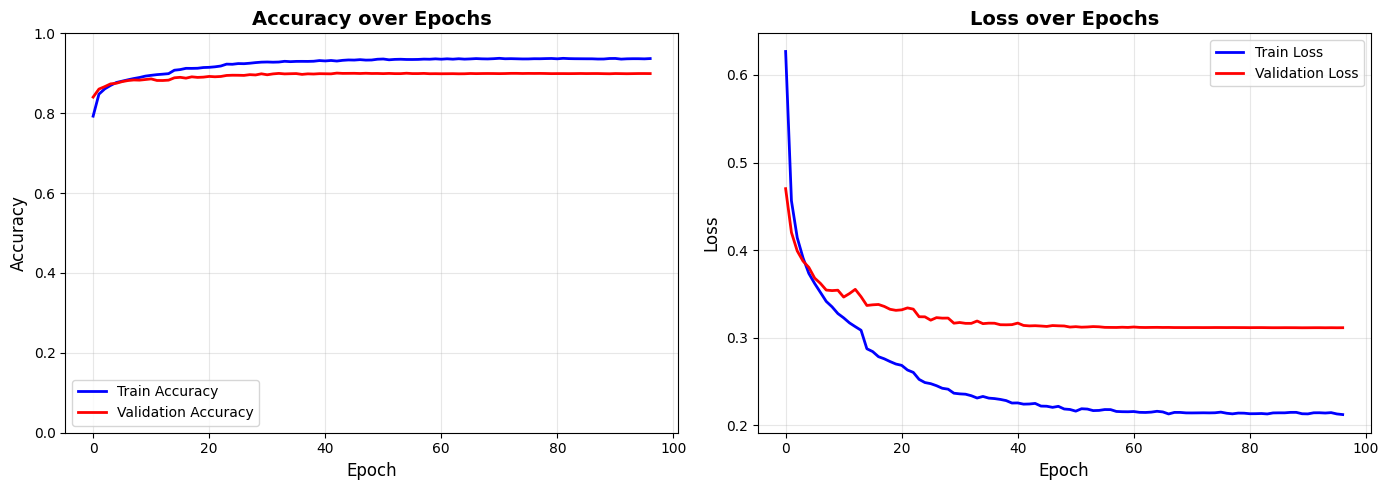


✓ Графік збережено: output_plots/training_history.png


In [23]:
# Створюємо директорію для графіків
os.makedirs('output_plots', exist_ok=True)
print("✓ Директорія 'output_plots' створена")

print("=" * 60)
print("ГРАФІК 1: Тренувальна історія (Accuracy та Loss)")
print("=" * 60)

plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], 'b-', label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy over Epochs', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], 'b-', label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Loss over Epochs', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output_plots/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Графік збережено: output_plots/training_history.png")

ГРАФІК 2: Confusion Matrix


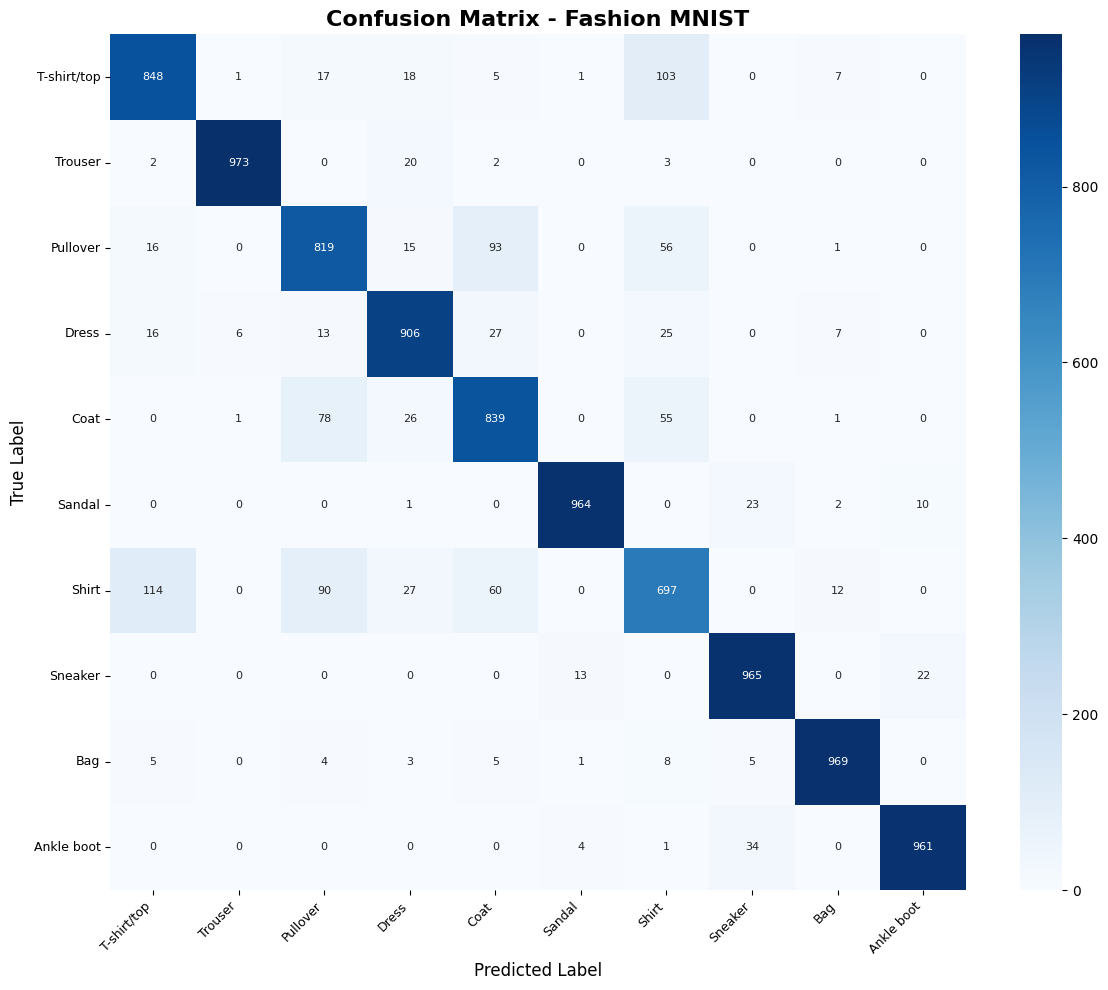


✓ Confusion Matrix збережено: output_plots/confusion_matrix.png


In [24]:
print("=" * 60)
print("ГРАФІК 2: Confusion Matrix")
print("=" * 60)

# Створюємо confusion matrix
cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={'size': 8})
plt.title('Confusion Matrix - Fashion MNIST', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('output_plots/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Confusion Matrix збережено: output_plots/confusion_matrix.png")

ГРАФІК 3: Точність по кожному класу


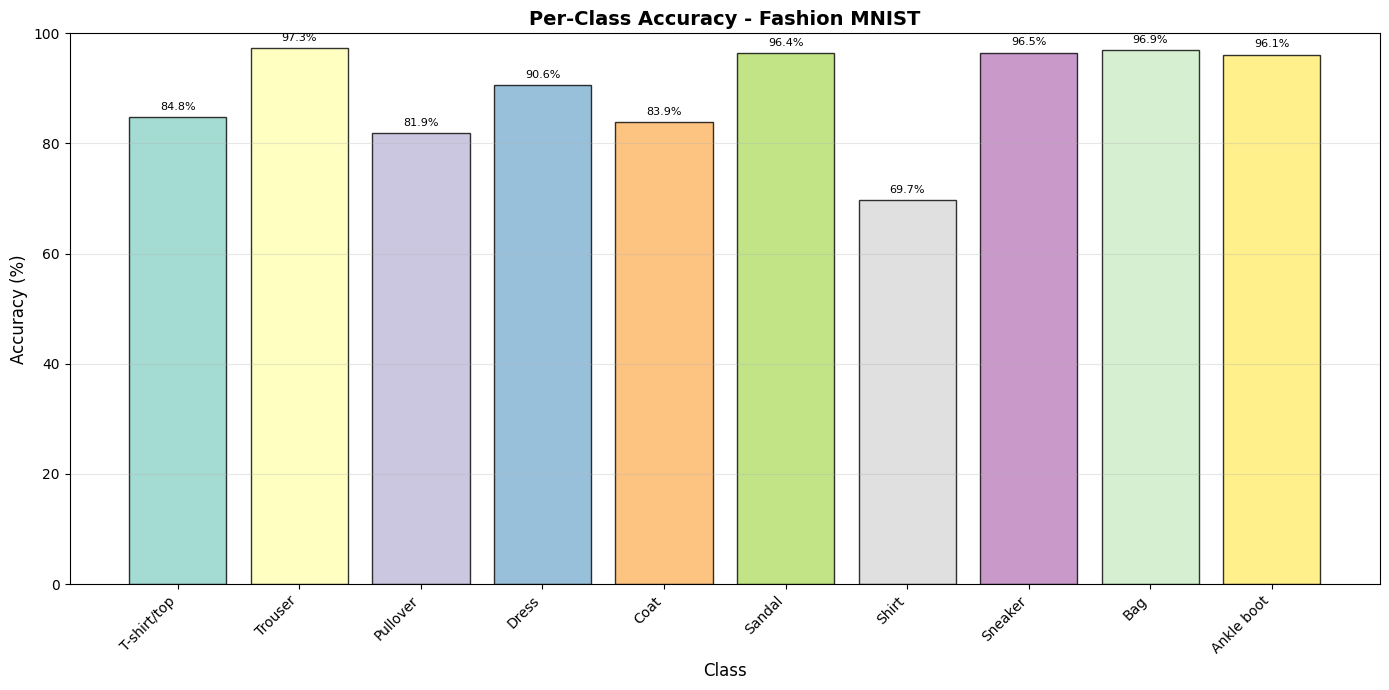


✓ Графік збережено: output_plots/per_class_accuracy.png


In [25]:
print("=" * 60)
print("ГРАФІК 3: Точність по кожному класу")
print("=" * 60)

# Розраховуємо точність по кожному класу
class_accuracy = np.diag(cm) / cm.sum(axis=1)

plt.figure(figsize=(14, 7))
colors = plt.cm.Set3(np.linspace(0, 1, len(class_names)))
bars = plt.bar(range(len(class_names)), class_accuracy * 100, color=colors, edgecolor='black', alpha=0.8)

# Додаємо значення на стовпчики
for bar, acc in zip(bars, class_accuracy * 100):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=8)

plt.xlabel('Class', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Per-Class Accuracy - Fashion MNIST', fontsize=14, fontweight='bold')
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right', fontsize=10)
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('output_plots/per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Графік збережено: output_plots/per_class_accuracy.png")

ГРАФІК 4: Приклади передбачень


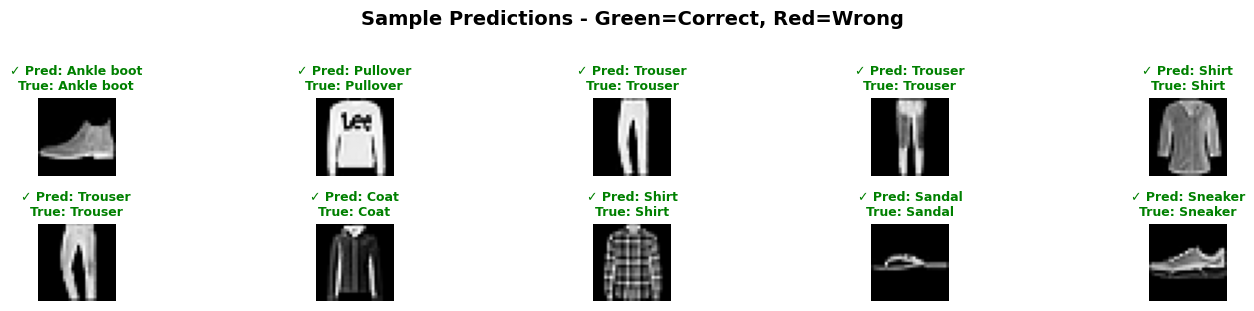


✓ Графік збережено: output_plots/sample_predictions.png


In [26]:
print("=" * 60)
print("ГРАФІК 4: Приклади передбачень")
print("=" * 60)

plt.figure(figsize=(15, 3))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i], cmap='gray')
    pred_label = predicted_labels[i]
    true_label = y_test[i]
    color = 'green' if pred_label == true_label else 'red'
    accuracy_symbol = '✓' if pred_label == true_label else '✗'
    plt.title(f"{accuracy_symbol} Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}", 
              color=color, fontsize=9, fontweight='bold')
    plt.axis('off')
plt.suptitle('Sample Predictions - Green=Correct, Red=Wrong', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output_plots/sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Графік збережено: output_plots/sample_predictions.png")

## 10. Детальний звіт про класифікацію

In [27]:
print("=" * 60)
print("ДЕТАЛЬНИЙ ЗВІТ ПРО КЛАСИФІКАЦІЮ")
print("=" * 60)

print(classification_report(y_test, predicted_labels, target_names=class_names))

ДЕТАЛЬНИЙ ЗВІТ ПРО КЛАСИФІКАЦІЮ
              precision    recall  f1-score   support

 T-shirt/top       0.85      0.85      0.85      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.80      0.82      0.81      1000
       Dress       0.89      0.91      0.90      1000
        Coat       0.81      0.84      0.83      1000
      Sandal       0.98      0.96      0.97      1000
       Shirt       0.74      0.70      0.72      1000
     Sneaker       0.94      0.96      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.97      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



## 11. Збереження моделі

In [28]:
# Зберігаємо найкращу модель
model_path = 'best_model_fully_connected.keras'
best_model.save(model_path)
print(f"✓ Модель збережена: {model_path}")

# Перевіряємо розмір файлу
import os
file_size = os.path.getsize(model_path) / (1024 * 1024)  # MB
print(f"✓ Розмір файлу: {file_size:.2f} MB")

✓ Модель збережена: best_model_fully_connected.keras
✓ Розмір файлу: 2.35 MB


## 12. Перевірка збереженої моделі

In [29]:
# Завантажуємо модель для перевірки
loaded_model = keras.models.load_model(model_path)

# Перевіряємо точність на тестовому наборі
_, loaded_accuracy = loaded_model.evaluate(x_test_flat, y_test_categorical, verbose=0)

print("=" * 60)
print("ПЕРЕВІРКА ЗАВАНТАЖЕНОЇ МОДЕЛІ")
print("=" * 60)
print(f"Точність збереженої моделі: {loaded_accuracy:.4f} ({loaded_accuracy * 100:.2f}%)")
print(f"Точність оригінальної моделі: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")
print(f"Різниця: {abs(loaded_accuracy - test_accuracy):.6f}")

if abs(loaded_accuracy - test_accuracy) < 0.0001:
    print("\n✓ Модель успішно збережена та завантажена!")
else:
    print("\n⚠ Є розбіжність у точності")

ПЕРЕВІРКА ЗАВАНТАЖЕНОЇ МОДЕЛІ
Точність збереженої моделі: 0.8941 (89.41%)
Точність оригінальної моделі: 0.8941 (89.41%)
Різниця: 0.000000

✓ Модель успішно збережена та завантажена!
